essay-->evaluation based on Clarity of thought
based on depth of analysis
based on language

then all llm will give two output.
1. text feedback for each evaluation.
2. score out of 0-10.
then all output from all three llm will
go to final llm which will again give a final feedback 
and average score.

In [11]:
from  langgraph.graph import StateGraph , START ,END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict ,Annotated
import operator
from pydantic import BaseModel ,Field
import os
load_dotenv()
OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")

model=ChatOpenAI(model="gpt-4o-mini")



In [12]:
# structured output
class EvaluationSchema(BaseModel):
    feedback:str=Field(description="This is the feedback for the essay ")
    score:int=Field(description="score to be given out of 10", ge=0, le=10)

In [13]:
# model with 

structuredModel=model.with_structured_output(EvaluationSchema)

In [14]:
essay="""Artificial Intelligence (AI) is transforming industries and societies across the globe, and in India, it holds exceptional promise. With a vast population, a rapidly growing digital ecosystem, and a strong base of technological talent, AI can become a powerful driver of growth, governance, and innovation. From improving everyday life to shaping national competitiveness, AI’s impact in India is both far-reaching and transformative.

In healthcare, AI is enabling early disease detection, predictive analytics, and telemedicine, making quality care more accessible, especially in rural areas. In agriculture, technologies such as precision farming, weather forecasting, and crop health monitoring are helping farmers increase yields and reduce losses. Education is also witnessing change, with AI-powered platforms delivering personalized learning experiences, automating administrative tasks, and bridging learning gaps for millions of students.

Beyond social sectors, AI is strengthening governance through automated public service systems, crime prediction tools, and digital assistants that make government services faster and more efficient. In industry, AI-driven automation is improving productivity, ensuring quality control, and streamlining supply chains, giving Indian businesses a competitive edge in global markets.

The economic potential is significant—AI could add hundreds of billions to India’s GDP over the coming decade. However, realizing this potential will require overcoming challenges such as data privacy concerns, a shortage of skilled professionals, ethical dilemmas, and uneven digital infrastructure. Addressing these issues is crucial for ensuring that AI benefits are widespread and equitable.

To fully harness AI’s promise, India must invest heavily in research and development, prioritize workforce upskilling, create strong data governance policies, and foster collaboration between the government, industry, and academia. With the right policies and safeguards in place, AI can become not just a technological advantage but a force for inclusive and sustainable growth, propelling India into a leadership role in the global AI landscape."""

In [15]:
class UPSCState(TypedDict):
    essay:str
    language_fedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_score: Annotated[list[int],operator.add]
    average_score:float

In [16]:
def evaluate_language(state:UPSCState)->UPSCState:
    essay=state['essay']
    prompt=f'Evaluate the Language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
    response=structuredModel.invoke(prompt)
    return {"language_fedback":response.feedback ,"individual_score":[response.score] }

def evaluate_analysis(state:UPSCState)->UPSCState:
    essay=state['essay']
    prompt=f'Evaluate the depth of  analysis of  the following essay and provide a feedback and assign a score out of 10 \n {essay}'
    response=structuredModel.invoke(prompt)
    return {"analysis_feedback":response.feedback ,"individual_score":[response.score] }


def evaluate_clarity(state:UPSCState)->UPSCState:
    essay=state['essay']
    prompt=f'Evaluate the clarity of thought of  the following essay and provide a feedback and assign a score out of 10 \n {essay}'
    response=structuredModel.invoke(prompt)
    return {"clarity_feedback":response.feedback ,"individual_score":[response.score] }


def evaluate_Overall(state:UPSCState)->UPSCState:
    essay=state['essay']
    clarity_feedback=state["clarity_feedback"]
    analysis_feedback=state["analysis_feedback"]
    language_fedback=state["language_fedback"]
    prompt=f'based on following feedback generate a overall summerized feedback. Language feedback-->\n {language_fedback}  clarity of thought feedback-->\n {clarity_feedback} language feedback--> \n{language_fedback}'
    response=model.invoke(prompt).content
    average_score=sum(state["individual_score"])/len(state["individual_score"])
    return {"overall_feedback":response ,"average_score":average_score}




In [17]:
from langgraph.graph import StateGraph , START ,END
from typing import TypedDict

In [18]:

graph=StateGraph(UPSCState)

graph.add_node("evaluate_clarity",evaluate_clarity)
graph.add_node("evaluate_analysis",evaluate_analysis)
graph.add_node("evaluate_language",evaluate_language)
graph.add_node("evaluate_Overall",evaluate_Overall)

# add edges
graph.add_edge(START,"evaluate_clarity")
graph.add_edge(START,"evaluate_analysis")
graph.add_edge(START,"evaluate_language")

graph.add_edge("evaluate_clarity","evaluate_Overall")
graph.add_edge("evaluate_analysis","evaluate_Overall")
graph.add_edge("evaluate_language","evaluate_Overall")

graph.add_edge("evaluate_Overall",END)

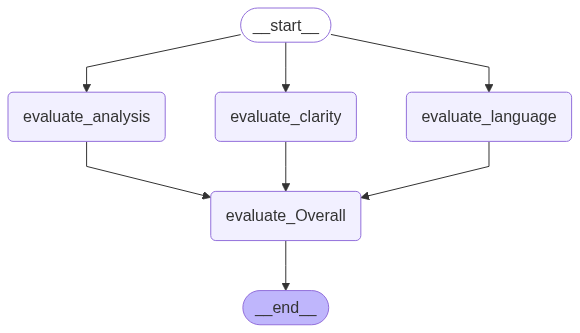

In [19]:
workflow=graph.compile()
workflow

In [22]:
initial_state={"essay":essay}
final_state=workflow.invoke(initial_state)

print(final_state)

{'essay': 'Artificial Intelligence (AI) is transforming industries and societies across the globe, and in India, it holds exceptional promise. With a vast population, a rapidly growing digital ecosystem, and a strong base of technological talent, AI can become a powerful driver of growth, governance, and innovation. From improving everyday life to shaping national competitiveness, AI’s impact in India is both far-reaching and transformative.\n\nIn healthcare, AI is enabling early disease detection, predictive analytics, and telemedicine, making quality care more accessible, especially in rural areas. In agriculture, technologies such as precision farming, weather forecasting, and crop health monitoring are helping farmers increase yields and reduce losses. Education is also witnessing change, with AI-powered platforms delivering personalized learning experiences, automating administrative tasks, and bridging learning gaps for millions of students.\n\nBeyond social sectors, AI is streng